# Install

In [ ]:
pip install git+https://github.com/imagdau/aseMolec@f411b5618381ba3b807cbbb041f12f460a69d606

  Cloning https://github.com/imagdau/aseMolec (to revision f411b5618381ba3b807cbbb041f12f460a69d606) to /tmp/pip-req-build-pjg59ynx
  Running command git clone --filter=blob:none --quiet https://github.com/imagdau/aseMolec /tmp/pip-req-build-pjg59ynx
  Running command git rev-parse -q --verify 'sha^f411b5618381ba3b807cbbb041f12f460a69d606'
  Running command git fetch -q https://github.com/imagdau/aseMolec f411b5618381ba3b807cbbb041f12f460a69d606
  Resolved https://github.com/imagdau/aseMolec to commit f411b5618381ba3b807cbbb041f12f460a69d606
  Preparing metadata (setup.py) ... done
  Created wheel for aseMolec: filename=aseMolec-1.0.0-py3-none-any.whl size=23162 sha256=bcad86d349fb7237a59609f930ee211806d92911cb8d12c024d16b91da32be83
  Stored in directory: /root/.cache/pip/wheels/bf/ab/ed/45f9be5430256a5678b55aeccaeb233ab05ac03514a7805562
Successfully built aseMolec


In [ ]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [ ]:
pip install mace-torch cuequivariance cuequivariance-torch cuequivariance-ops-torch-cu12 torch-dftd

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.7/266.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.8/197.8 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.6/30.6 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.7/681.7 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Import

In [ ]:
import os
from ase.io import write, read
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Função Auxiliar para DM no ASE

In [ ]:
np.random.seed(701) #fixa uma seed aleatória

def simpleMD(init_conf, temp, calc, fname, s, T):
    init_conf.calc = calc

    MaxwellBoltzmannDistribution(init_conf, temperature_K=300)
    Stationary(init_conf)
    ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 0.5*units.fs, temperature_K=temp, friction=0.1)

    time_fs = []
    temperature = []
    energies = []

    os.system('rm -rfv '+fname) #limpa o arquivo de dados prévios com mesmo nome

    fig, ax = plt.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

    def write_frame():
            dyn.atoms.info['energy_mace'] = dyn.atoms.get_potential_energy()
            dyn.atoms.arrays['forces_mace'] = dyn.atoms.calc.get_forces()
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

            ax[0].plot(np.array(time_fs), np.array(energies), color="b")
            ax[0].set_ylabel('E (eV/atom)')

            ax[1].plot(np.array(time_fs), temperature, color="r")
            ax[1].set_ylabel('T (K)')
            ax[1].set_xlabel('Time (fs)')

            display.clear_output(wait=True)
            display.display(plt.gcf())
            time.sleep(0.01)

    dyn.attach(write_frame, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

# MD com Mace

In [ ]:
from mace.calculators import mace_mp

macemp = mace_mp(model="small", dispersion=True, default_dtype = "float32", device="cuda")

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


Cached MACE model to /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.
Using TorchDFTD3Calculator for D3 dispersion corrections


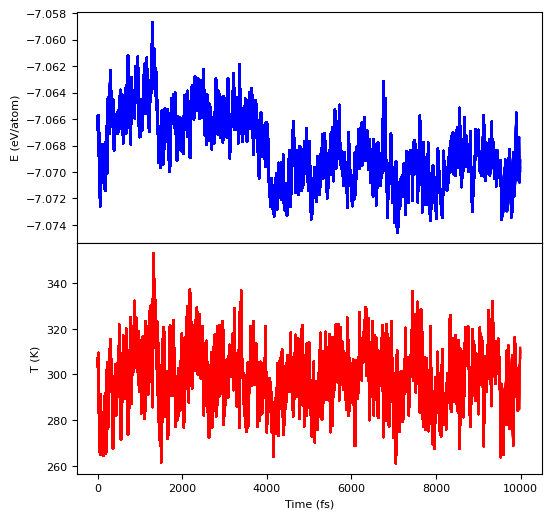

MD finished in 210.09 minutes!


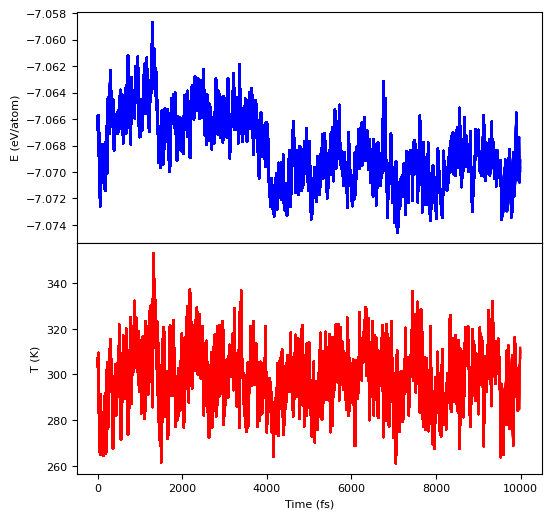

In [ ]:
init_conf = read('/content/drive/MyDrive/COQ878_TRABALHO/frame_900.pdb')

simpleMD(init_conf, temp=300, calc=macemp, fname='/content/drive/MyDrive/COQ878_TRABALHO/frame_900_product.xyz', s=10, T=20000)